Load models from Bradley-Terry/ModelPool

In [1]:

from CatanSimulator import RunGame
import random
from DeepLearning.Thesis.Environments.DummyEnv import DummyEnv
from DeepLearning.PPO import MaskablePPO
from Agents.AgentRandom2 import AgentRandom2
from Agents.AgentUCT import AgentUCT
from Agents.AgentModel import AgentMultiModel
from Client.DeepLearning.Encoders.MainGame.Observation.get_observation_full import getObservationFull
from Client.DeepLearning.Encoders.MainGame.ActionMask.GetActionMask import getActionMask
from Client.DeepLearning.Encoders.Setup.ActionMask.getSetupActionMask import getSetupActionMask
from Client.DeepLearning.Encoders.Setup.Observation.getObservationSetup import getObservationSetup

agent_list = ["UCT100"]

def load_models_from_folder(folder_path):
    model_list = []

    for file in os.listdir(folder_path):
        full_path = os.path.join(folder_path, file)

        # 只保留文件，不要子目录
        if os.path.isfile(full_path):
            model_list.append(file)

    return model_list



ImportError: DLL load failed while importing _multiarray_umath: 找不到指定的模块。

ImportError: DLL load failed while importing _multiarray_umath: 找不到指定的模块。

ModuleNotFoundError: No module named 'DeepLearning.GetActionMask'

In [8]:

import os

_GLOBAL_SETUP_MODEL = None

def load_model_agent(model_name, seat_number, env):
    """
    根据模型名加载 agent
    """
    global _GLOBAL_SETUP_MODEL

    if model_name == "UCT50":
        return AgentUCT(name=f"P{seat_number}",
                        seatNumber=seat_number,
                        simulationCount = 50)
    if model_name == "UCT100":
        return AgentUCT(name=f"P{seat_number}",
                        seatNumber=seat_number,
                        simulationCount = 100)
    if model_name == "Random":
        return AgentRandom2(name=f"P{seat_number}",
                            seatNumber=seat_number)
    
    # 加载开局模型 (Setup Model) - 只加载一次
    if _GLOBAL_SETUP_MODEL is None:
        setup_path = "DeepLearning/Models/ZKA_model/ZKA_SetupStage_1M.zip"
        if not os.path.exists(setup_path):
            raise FileNotFoundError(f"Setup model not found at: {setup_path}")
        print("Loading Setup Model into memory for evaluation...")
        _GLOBAL_SETUP_MODEL = MaskablePPO.load(setup_path, device="cpu")

    # 根据模型名加载对战的 Gameplay 模型
    model_path = os.path.join("Bradley-Terry", "ModelPool", model_name)

    if not os.path.exists(model_path):
        raise FileNotFoundError(f"Model not found: {model_path}")

    gameplay_model = MaskablePPO.load(model_path, env=env, device="cpu")

    return AgentMultiModel(
        name=f"P{seat_number}",
        seatNumber=seat_number,
        setupModel=_GLOBAL_SETUP_MODEL,
        setup_obs_func=getObservationSetup,
        setup_mask_func=getSetupActionMask,
        gameplayModel=gameplay_model,
        gameplay_obs_func=getObservationFull,
        gameplay_mask_func=getActionMask,
        fullSetup=True
    )


def load_win_matrix(filename="Bradley-Terry/bt_matrix.csv"):
    # Check if file exists AND is not empty
    if os.path.exists(filename) and os.path.getsize(filename) > 0:
        try:
            df = pd.read_csv(filename, index_col=0)
            return df
        except pd.errors.EmptyDataError:
            # Fallback if getsize missed something or file is just whitespace
            print(f"Warning: {filename} is empty.")
            return pd.DataFrame()
    else:
        # If file doesn't exist or is 0 bytes, return empty DF
        return pd.DataFrame()

def ensure_model_exists(df, model_name):
    if model_name not in df.index:
        # 新模型列表
        new_models = list(df.index) + [model_name]

        # 重新构造完整方阵
        df = df.reindex(index=new_models, columns=new_models, fill_value=0)

    return df

def update_from_game(df, selected, winner_index):
    winner = selected[winner_index]

    # 先保证所有模型存在
    for model in selected:
        df = ensure_model_exists(df, model)

    # winner 胜其他人
    for model in selected:
        if model != winner:
            df.loc[winner, model] += 1

    return df

def save_win_matrix(df, filename="Bradley-Terry/bt_matrix.csv"):
    df.to_csv(filename)


Run simulation and update results to Win Matrix

In [25]:
import gc

model_list = load_models_from_folder("Bradley-Terry/ModelPool")
# print model_list

model_list = model_list + agent_list

simulate_games = 2000

win_matrix = load_win_matrix()

for i in range(simulate_games):
    try:
        selected = random.sample(model_list, 4) # 随机抽4个模型

        players = [
            load_model_agent(selected[0], 0, env = DummyEnv()),
            load_model_agent(selected[1], 1, env = DummyEnv()),
            load_model_agent(selected[2], 2, env = DummyEnv()),
            load_model_agent(selected[3], 3, env = DummyEnv()),
        ]

        winner = RunGame(players = players)
        print("Game <" + str(i) + ">: " + selected[winner] + " wins.")

        win_matrix = update_from_game(win_matrix, selected, winner)

        if i % 10 == 5:
            print("win_matrix Updated!")
            save_win_matrix(win_matrix)

    except Exception as e:
        # 如果报错，打印错误信息并跳过当前循环
        print(f"Game <{i}> crashed! Error: {e}")
        # traceback.print_exc()  # 如果你想看完整的报错长代码，可以取消这行的注释
        continue

    finally:
        # 🟢 手动释放 (放在 finally 里，保证不管报没报错都会执行)
        if 'players' in locals():
            del players
        gc.collect()  # 强制回收

Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


D:\ProgramData\Anaconda3_\envs\catan\Lib\site-packages\stable_baselines3\common\utils.py:168: UserWarning: get_schedule_fn() is deprecated, please use FloatSchedule() instead
  warnings.warn("get_schedule_fn() is deprecated, please use FloatSchedule() instead")


Game <0>: model_6536698_43.zip wins.
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Game <1>: model_6673525_39.zip wins.
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Game <2>: UCT100 wins.
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Game <3>: UCT100 wins.
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Wrapping the env with a `Monitor`

KeyboardInterrupt: 

Get Bradley-Terry according to Win Matrix

In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def bradley_terry_score(win_matrix, max_iter=1000, tol=1e-6, eps=1e-8):
    """
    用迭代法计算 Bradley-Terry 模型评分（避免胜率为0报错）
    win_matrix: DataFrame, 行i列j表示i胜j的次数
    eps: 避免0值的小常数
    """
    items = win_matrix.index.tolist()
    n = len(items)

    W = win_matrix.values.astype(float)

    # 初始化每个模型的能力值 pi，避免0
    p = np.ones(n) * 0.5

    for iteration in range(max_iter):
        p_old = p.copy()
        for i in range(n):
            numerator = 0
            denominator = 0
            for j in range(n):
                if i == j:
                    continue
                numerator += W[i, j] * p[j] / max(p[i] + p[j], eps)
                denominator += W[j, i] / max(p[i] + p[j], eps)
            # 避免除0
            if denominator > 0:
                p[i] = numerator / denominator
            else:
                p[i] = eps  # 如果全0就给个小值
        # 归一化，避免0
        p = np.maximum(p, eps)
        p = p / (np.prod(p) ** (1/n))
        if np.max(np.abs(p - p_old)) < tol:
            break

    # 转成 Elo 风格分数
    elo_scores = 400 * np.log10(p)
    return pd.Series(elo_scores, index=items)

# 使用示例
win_matrix = load_win_matrix()
bt_scores = bradley_terry_score(win_matrix)

bt_scores = bt_scores.clip(lower=0)

print(bt_scores)


model_6223354_elo332.zip                             233.137188
ZKA_FullObservation_GameplayStage_5M_Dense.zip       211.749850
model_7971957_4.zip                                  268.758811
model_6659578_39.zip                                 255.138970
model_6673525_39.zip                                 290.281502
model_6536698_43.zip                                 246.588178
Random                                                 0.000000
UCT50                                                173.354397
model_6544890_46.zip                                 211.420643
model_7980149_5.zip                                  349.546138
ZKA_FullObservation_GameplayStage_7M_Selfplay.zip    171.849092
UCT100                                               401.362656
model_8987765_7.zip                                  386.812566
dtype: float64


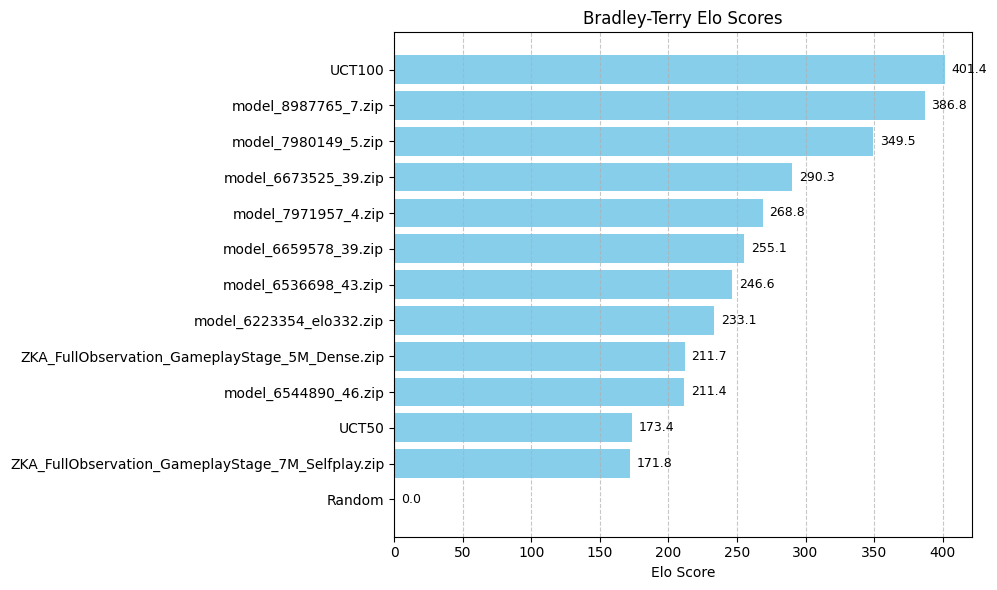

In [27]:
def plot_bt_scores(bt_scores, title="Bradley-Terry Elo Scores"):
    """
    绘制模型分数的条形图
    """
    # 按分数排序
    bt_scores_sorted = bt_scores.sort_values(ascending=True)

    plt.figure(figsize=(10, 6))
    bars = plt.barh(bt_scores_sorted.index, bt_scores_sorted.values, color='skyblue')

    # 显示数值
    for bar in bars:
        width = bar.get_width()
        plt.text(width + 5, bar.get_y() + bar.get_height()/2,
                 f'{width:.1f}', va='center', fontsize=9)

    plt.xlabel("Elo Score")
    plt.title(title)
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

plot_bt_scores(bt_scores)
